Tuning Classification Models (Threshold: 20)...
Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.

Average Classification Metrics (Threshold >= 20):
Dummy_Baseline_Accuracy        0.558261
Dummy_Baseline_F1              0.603605
Dummy_Baseline_AUC             0.500000
LogisticRegression_Accuracy    0.610435
LogisticRegression_F1          0.707853
LogisticRegression_AUC         0.593457
RandomForest_Accuracy          0.629565
RandomForest_F1                0.717089
RandomForest_AUC               0.616618
XGBoost_Accuracy               0.624348
XGBoost_F1                     0.686409
XGBoost_AUC                    0.632953
SVM_Accuracy                   0.584348
SVM_F1                         0.701330
SVM_AUC                        0.587802
dtype: float64


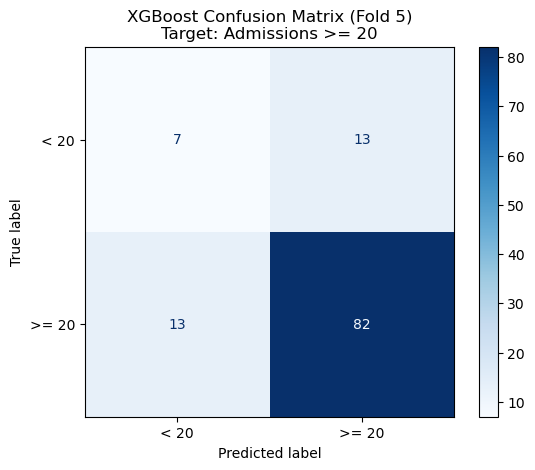

In [2]:
import os
import numpy as np
import pandas as pd
import optuna
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import RobustScaler
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- CONFIGURATION ---
THRESHOLD = 20  
LAG_DAYS = [1, 3, 7]
ROLL_WINDOWS = [3, 7]
TARGET_COL = "Number of Admissions"
WIND_DIR_COL = "wind_direction_10m_dominant (°)"
N_SPLITS = 5
N_TRIALS = 25
RANDOM_STATE = 42

# --- 1. FEATURE ENGINEERING ---
def engineer_features(df):
    df = df.copy()
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df = df.sort_values('Timestamp').reset_index(drop=True)
    
    # Cyclical Seasonality
    df["dow_sin"] = np.sin(2 * np.pi * df['Timestamp'].dt.dayofweek / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df['Timestamp'].dt.dayofweek / 7)
    df["month_sin"] = np.sin(2 * np.pi * df['Timestamp'].dt.month / 12)
    df["month_cos"] = np.cos(2 * np.pi * df['Timestamp'].dt.month / 12)
    df["weekend"] = (df['Timestamp'].dt.dayofweek >= 5).astype(int)
    
    if WIND_DIR_COL in df.columns:
        df["wind_sin"] = np.sin(2 * np.pi * df[WIND_DIR_COL] / 360)
        df["wind_cos"] = np.cos(2 * np.pi * df[WIND_DIR_COL] / 360)

    exclude = ['Timestamp', TARGET_COL, WIND_DIR_COL, 'Date']
    weather_cols = [c for c in df.columns if c not in exclude and pd.api.types.is_numeric_dtype(df[c])]
    
    new_feats = {}
    for col in weather_cols:
        for lag in LAG_DAYS:
            new_feats[f"{col}_lag{lag}"] = df[col].shift(lag)
        for roll in ROLL_WINDOWS:
            new_feats[f"{col}_roll{roll}"] = df[col].shift(1).rolling(roll).mean()
            
    
    new_feats["admission_lag7"] = df[TARGET_COL].shift(7)
    
    df = pd.concat([df, pd.DataFrame(new_feats)], axis=1).dropna().reset_index(drop=True)
    df['target_binary'] = (df[TARGET_COL] >= THRESHOLD).astype(int)
    return df

# --- 2. TUNING LOGIC ---
def get_optuna_params(model_type, X_tr, y_tr, X_va, y_va):
    def objective(trial):
        if model_type == 'rf':
            p = {'n_estimators': trial.suggest_int("n_estimators", 50, 200), 
                 'max_depth': trial.suggest_int("max_depth", 5, 20)}
            model = RandomForestClassifier(**p, random_state=RANDOM_STATE, n_jobs=-1)
        elif model_type == 'xgb':
            p = {'n_estimators': trial.suggest_int("n_estimators", 50, 300), 
                 'max_depth': trial.suggest_int("max_depth", 3, 10), 
                 'learning_rate': trial.suggest_float("learning_rate", 0.01, 0.2, log=True)}
            model = xgb.XGBClassifier(**p, random_state=RANDOM_STATE, eval_metric='logloss')
        
        model.fit(X_tr, y_tr)
        return f1_score(y_va, model.predict(X_va)) 

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=N_TRIALS)
    return study.best_params

# --- 3. EVALUATION LOOP ---
df = engineer_features(pd.read_csv("/Users/suhaniagarwal/Downloads/all_features_data.csv"))
feat_cols = [c for c in df.columns if any(s in c for s in ["_lag", "_roll", "sin", "cos", "weekend"])]
X, y = df[feat_cols], df['target_binary']


tscv = TimeSeriesSplit(n_splits=N_SPLITS)
fold_results = []
best_params = {}

last_y_test, last_y_preds = None, None

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    scaler = RobustScaler() 
    X_train_s, X_test_s = scaler.fit_transform(X_train), scaler.transform(X_test)
    
    if fold == 0:
        print(f"Tuning Classification Models (Threshold: {THRESHOLD})...")
        split = int(len(X_train_s) * 0.8)
        for m in ['rf', 'xgb']:
            best_params[m] = get_optuna_params(m, X_train_s[:split], y_train.iloc[:split], 
                                                X_train_s[split:], y_train.iloc[split:])

    models = {
        
        "Dummy_Baseline": DummyClassifier(strategy="most_frequent"),
        "LogisticRegression": LogisticRegressionCV(cv=5),
        "RandomForest": RandomForestClassifier(**best_params['rf']),
        "XGBoost": xgb.XGBClassifier(**best_params['xgb']),
        "SVM": SVC(probability=True)
    }
    
    scores = {}
    for name, model in models.items():
        model.fit(X_train_s, y_train)
        preds = model.predict(X_test_s)
        
        scores[f"{name}_Accuracy"] = accuracy_score(y_test, preds)
        scores[f"{name}_F1"] = f1_score(y_test, preds)
        
        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(X_test_s)[:, 1]
            scores[f"{name}_AUC"] = roc_auc_score(y_test, probs)

        if fold == N_SPLITS - 1 and name == "XGBoost":
            last_y_test = y_test
            last_y_preds = preds
    
    fold_results.append(scores)
    print(f"Fold {fold+1} complete.")

# --- 4. OUTPUT ---
print(f"\nAverage Classification Metrics (Threshold >= {THRESHOLD}):")
print(pd.DataFrame(fold_results).mean())

cm = confusion_matrix(last_y_test, last_y_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"< {THRESHOLD}", f">= {THRESHOLD}"])
disp.plot(cmap=plt.cm.Blues)
plt.title(f"XGBoost Confusion Matrix (Fold 5)\nTarget: Admissions >= {THRESHOLD}")
plt.show()